# Point Spread Function (PSF)

Response of a camera system to a point source (impulse)

## Gaussian PSF
$h(x,y) = \frac{1}{2\pi\sigma^2}\,e^{-\frac{x^2 + y^2}{2\sigma^2}}$




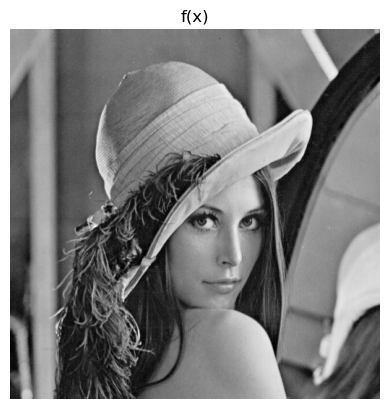

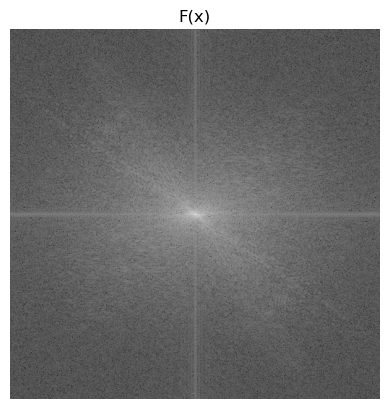

In [19]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from DiscreteFourierTransform import myfft,myinvfft
from helper_functions import plotPDF,dispImg,dispFreqDomainAmplitude
from Histograms_and_point_operations import create_histogram



def createGaussianPSF(sigma:int = 10,psf_size:tuple | None = None):

    if psf_size is None:
         psf_size = (int(3*sigma +1),int(3*sigma +1))

    h, w = psf_size

    x = np.arange(w) - w // 2   # Spalten
    y = np.arange(h) - h // 2   # Zeilen
    X, Y = np.meshgrid(x, y)

    pointSpreadGaus = 1/(2*np.pi*sigma**2) * np.exp(-(X**2 + Y**2)/(2*sigma**2))
    pointSpreadGaus /=pointSpreadGaus.sum()
    return pointSpreadGaus

f_x = cv2.imread("lena.bmp",cv2.IMREAD_UNCHANGED)
dispImg(f_x,"f(x)")
F = np.fft.fft2(f_x)
dispFreqDomainAmplitude(F,title="F(x)")



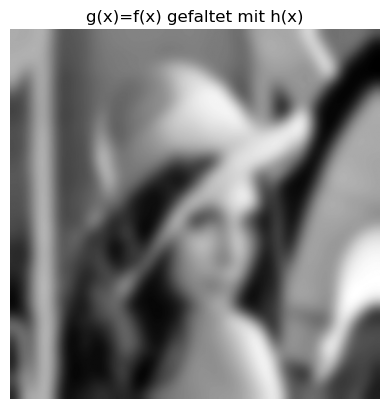

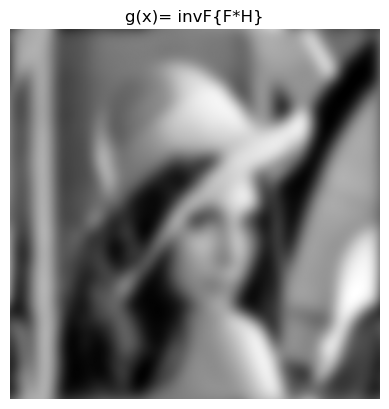

In [20]:
# create and apply gaussian PSF:
h_x_padded_zentriert = createGaussianPSF(sigma=10,psf_size=(f_x.shape[0],f_x.shape[1]))
blured_img = cv2.filter2D(f_x,-1,h_x_padded_zentriert)
dispImg(blured_img,"g(x)=f(x) gefaltet mit h(x)")


h_x_padded = np.fft.ifftshift(h_x_padded_zentriert)
H = np.fft.fft2(h_x_padded)
G = F*H
g = np.fft.ifft2(G)
dispImg(g,"g(x)= invF{F*H}")

# Restauration mit InversFilter
Im Orstraum: $g(x,y) = (f \ast h)(x,y) + n(x,y)$  
Im Frequenzraum: $G(u,v) = H(u,v)\,F(u,v) + N(u,v)$


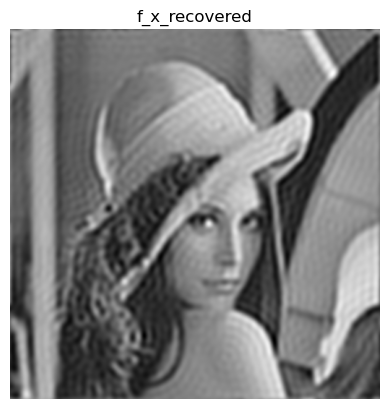

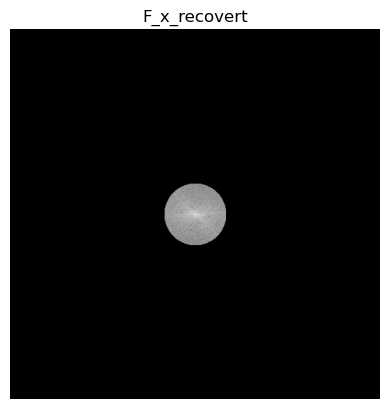

In [21]:
#  denoise mit Inversfilter
F_x_rec= np.zeros_like(G)
mask = np.abs(H) > 1e-6

F_x_rec[mask]= G[mask]/H[mask]
f_x_rec = np.fft.ifft2(F_x_rec)
dispImg(f_x_rec,"f_x_recovered")
dispFreqDomainAmplitude(F_x_rec,"F_x_recovert")


# Probability Density Functions (PDF)
noise component modeled as image of same size as the input image, filled with ramdom numbers that follow a certain pobability function

## PDF of a Gaussian

$$
p(z) = \frac{1}{\sqrt{2\pi}\,\sigma}
\,e^{-\frac{(z - \hat{z})^2}{2\sigma^2}}, 
\quad -\infty < z < \infty
$$
where $z$ is intensity and $\hat{z}$ is the mean (average) value of $z$.





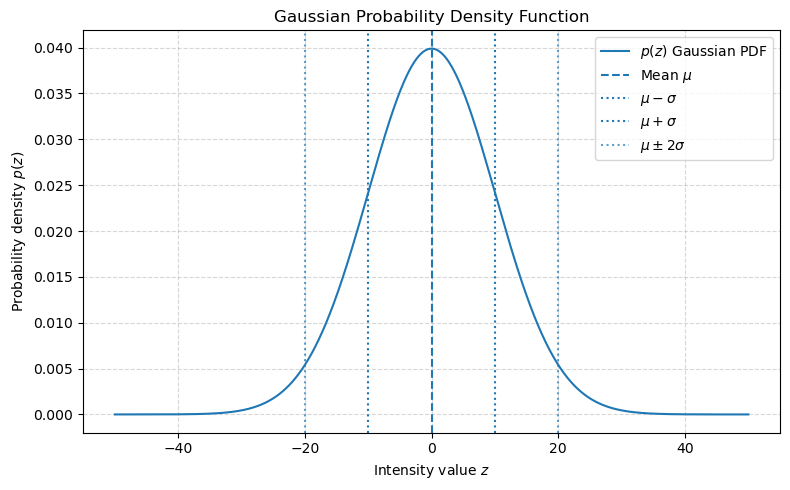

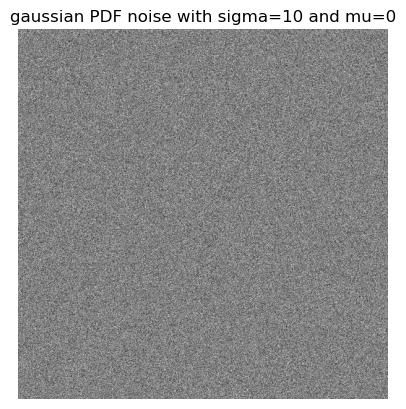

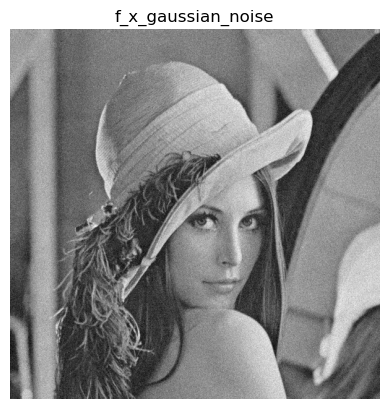

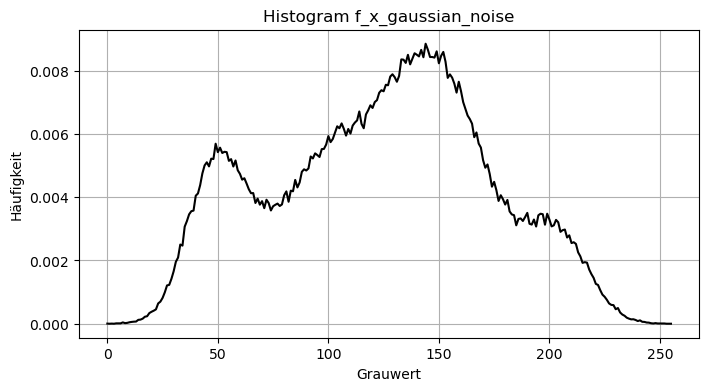

In [32]:

mu = 0.0
sigma = 10.0
z = np.linspace(-5*sigma, 5*sigma, 1000)
pdf = (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-((z - mu)**2) / (2*sigma**2))
plotPDF(z,pdf,mu,sigma)

pdf_norm = pdf/pdf.sum()

noise = np.random.choice(z,size=f_x.shape[:2],p=pdf_norm)
dispImg(noise,"gaussian PDF noise with sigma=10 and mu=0")
f_x_gaussian_noise = f_x.astype(dtype=np.float32) + noise.astype(dtype=np.float32)
dispImg(f_x_gaussian_noise,"f_x_gaussian_noise")
hist_gaus = create_histogram(f_x_gaussian_noise,verbose=True,title="Histogram f_x_gaussian_noise")



## Salt-and-Pepper Noise

Salt-and-pepper noise, also known as impulse noise, is characterized by
randomly occurring black and white pixels in an image.
Affected pixels are replaced by either the minimum or the maximum
intensity value with a certain probability.

Let $p_s$ denote the probability of salt noise and $p_p$ the probability
of pepper noise.

$$
z =
\begin{cases}
0,        & \text{with probability } p_p \\
2^8 - 1,  & \text{with probability } p_s \\
z_0,      & \text{with probability } 1 - p_s - p_p
\end{cases}
$$

where $z_0$ denotes the original pixel intensity.
Typically, $p_s = p_p = \tfrac{p}{2}$, where $p$ is the overall noise density.

example with $P=0.03$, $P_s=0.02$, $P_p=0.01$:



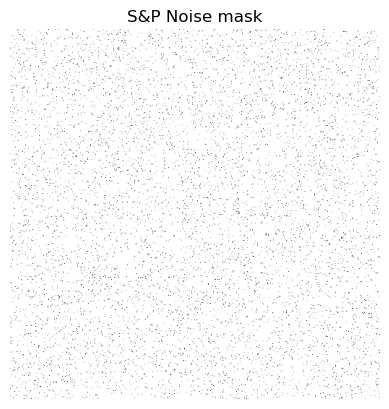

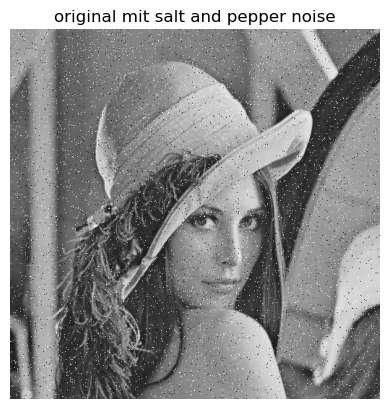

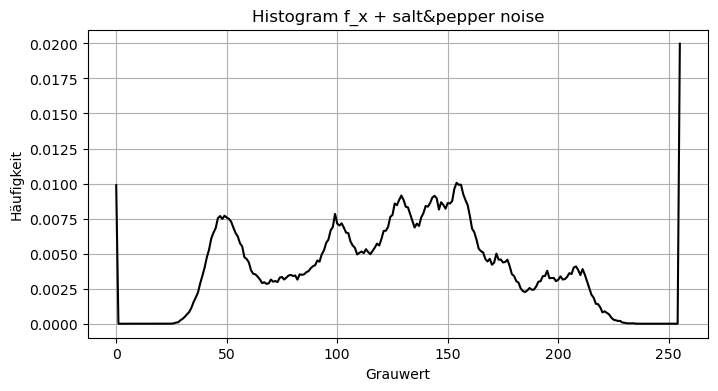

In [ ]:
P = 0.03
P_s = 0.02
P_p = 0.01
P_n = 1-P_s -P_p
# salt and pepper maske: 0 -> wert auf 0 setzten = pepper
#                        1 -> wert auf 255 setzen = salt
#                        2 -> wert unverändert lassen
mask_vals = np.array([0,1,2])
val_pobabilities = np.array([P_p,P_s,P_n])
mask = np.random.choice(mask_vals,size=f_x.shape,p=val_pobabilities)
dispImg(mask,"S&P Noise mask")

f_saltpepper = f_x.copy()
f_saltpepper[mask==0] = 0
f_saltpepper[mask==1] = 255
dispImg(f_saltpepper,"original mit salt and pepper noise")
hist_saltPepper = create_histogram(f_saltpepper,verbose=True,title="Histogram f_x + salt&pepper noise")


## Estimating Noise Parameters

Noise parameters can be estimated from small image patches $S$ that have a reasonably constant background intensity.
For each patch, compute the histogram and compare its shape to typical noise models (e.g., Gaussian, Rayleigh, impulse noise).
Then estimate the mean and variance of the intensity distribution.

Let $L$ be the number of possible intensity levels (8-bit: $L = 256$).
Let $z_i$ denote the $i$-th intensity level, with $i \in \{0,1,\dots,L-1\}$.
Let $\hat{p}_S(z_i)$ be the estimated probability of observing intensity $z_i$ in patch $S$
(i.e., the normalized histogram value).

### Mean

$$
\hat{z} = \sum_{i=0}^{L-1} z_i \, p_S(z_i)
$$

### Variance

$$
\sigma^2 = \sum_{i=0}^{L-1} (z_i - \hat{z})^2 \, p_S(z_i)
$$


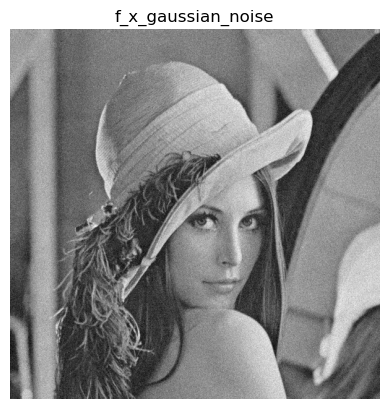

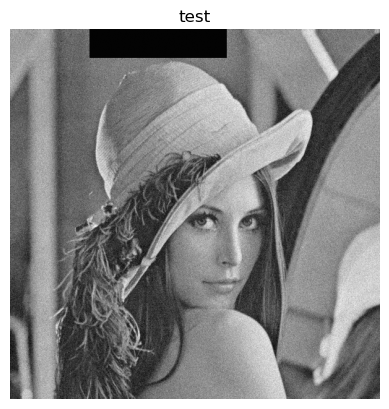

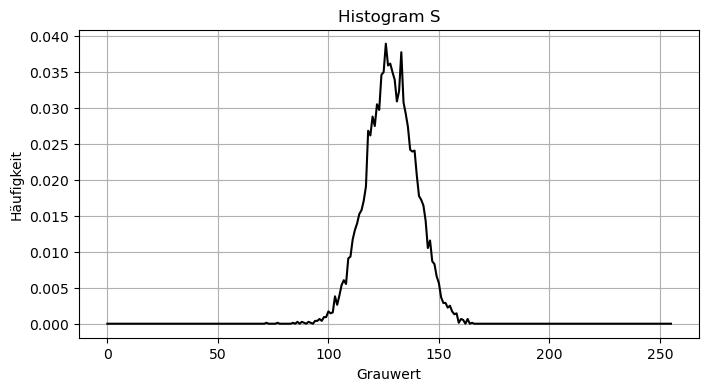

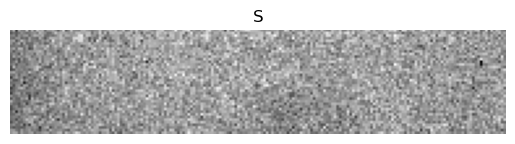

estimated sigma = 11.15757717708481
estimatet z_mean = 128.25710526315788


In [40]:
dispImg(f_x_gaussian_noise,"f_x_gaussian_noise")

# ausschnitt visualisieren
test = f_x_gaussian_noise.copy()
test[0:40,110:300] = 0
dispImg(test,"test")


S = f_x_gaussian_noise[0:40,110:300]
hist_S = create_histogram(S,verbose=True,title="Histogram S")
dispImg(S,"S")
p_s = hist_S / hist_S.sum()
zi = np.arange(256)
z_mean = np.sum(zi*p_s)

variance = np.sum((zi - z_mean)**2 * p_s)
sigma = np.sqrt(variance)
print(f"estimated sigma = {sigma}\nestimatet z_mean = {z_mean}")
